In [1]:
# ============================================================
# SUPPLY CHAIN INTELLIGENCE SYSTEM
# Notebook 4: Inventory Health & Dead Stock Detection
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# ============================================================
# Load data
# ============================================================

processed_path = r'D:\Projects\End-to-end projects\8. Supply Chain Intelligence\Data\Processed'

df_inventory = pd.read_csv(processed_path + r'\inventory_snapshots_clean.csv',
                           parse_dates=['snapshot_date'])
df_products  = pd.read_csv(processed_path + r'\products_clean.csv')
df_sales     = pd.read_csv(processed_path + r'\sales_orders_clean.csv',
                           parse_dates=['order_date'])

print("✅ Data loaded successfully!")
print(f"Inventory Snapshots: {len(df_inventory):,} rows")
print(f"Products:            {len(df_products)} SKUs")
print(f"Sales Orders:        {len(df_sales):,} rows")

✅ Data loaded successfully!
Inventory Snapshots: 15,750 rows
Products:            50 SKUs
Sales Orders:        2,600 rows


In [3]:
# ============================================================
# STEP 1: ABC ANALYSIS
# Segment SKUs by revenue contribution
# A = Top 70% of revenue
# B = Next 20% of revenue
# C = Bottom 10% of revenue
# ============================================================

# Calculate total revenue per SKU from sales data
sku_revenue = df_sales.groupby('sku_id').agg(
    total_revenue_inr  = ('gross_revenue_inr', 'sum'),
    total_units_sold   = ('units_fulfilled',   'sum'),
    total_orders       = ('order_id',          'count')
).reset_index()

# Sort by revenue descending
sku_revenue = sku_revenue.sort_values('total_revenue_inr', ascending=False).reset_index(drop=True)

# Cumulative revenue percentage
sku_revenue['cumulative_revenue'] = sku_revenue['total_revenue_inr'].cumsum()
sku_revenue['cumulative_pct']     = sku_revenue['cumulative_revenue'] / sku_revenue['total_revenue_inr'].sum() * 100
sku_revenue['revenue_pct']        = sku_revenue['total_revenue_inr'] / sku_revenue['total_revenue_inr'].sum() * 100

# Assign ABC category
def assign_abc(cumulative_pct):
    if cumulative_pct <= 70:
        return 'A'
    elif cumulative_pct <= 90:
        return 'B'
    else:
        return 'C'

sku_revenue['abc_category'] = sku_revenue['cumulative_pct'].apply(assign_abc)

# Merge with products
sku_revenue = sku_revenue.merge(
    df_products[['sku_id', 'product_name', 'category',
                 'unit_cost_inr', 'selling_price_inr', 'shelf_life_days']],
    on='sku_id', how='left'
)

print("✅ ABC Analysis complete!")
print(f"\n{'Category':<10} {'SKU Count':>10} {'Revenue (₹)':>18} {'% of Total':>12}")
print("-" * 55)
for cat in ['A', 'B', 'C']:
    subset = sku_revenue[sku_revenue['abc_category'] == cat]
    print(f"{cat:<10} {len(subset):>10} {subset['total_revenue_inr'].sum():>18,.0f} {subset['revenue_pct'].sum():>11.1f}%")

print(f"\nTop 5 Revenue SKUs:")
print(sku_revenue[['sku_id','product_name','abc_category',
                   'total_revenue_inr','revenue_pct']].head().to_string(index=False))

✅ ABC Analysis complete!

Category    SKU Count        Revenue (₹)   % of Total
-------------------------------------------------------
A                  23         38,853,447        68.2%
B                  14         12,305,315        21.6%
C                  13          5,795,141        10.2%

Top 5 Revenue SKUs:
sku_id                 product_name abc_category  total_revenue_inr  revenue_pct
SKU011 Cold Press Coconut Oil 500ml            A         3851424.50         6.76
SKU016             Rose Water 200ml            A         2537291.89         4.45
SKU039           Rose Sherbet 750ml            A         2483143.86         4.36
SKU020              Face Scrub 100g            A         2096736.72         3.68
SKU014           Aloe Vera Gel 150g            A         2053922.16         3.61


In [4]:
# ============================================================
# STEP 2: XYZ ANALYSIS
# Segment SKUs by demand variability
# X = CV < 0.5  → Stable demand
# Y = CV 0.5-1  → Moderate variability
# Z = CV > 1.0  → Erratic demand
# CV = Coefficient of Variation = std/mean
# ============================================================

# Weekly demand per SKU across all warehouses combined
weekly_demand = df_inventory.groupby(['snapshot_date', 'sku_id'])['units_sold'].sum().reset_index()

# Calculate CV per SKU
xyz_stats = weekly_demand.groupby('sku_id')['units_sold'].agg(
    mean_demand = 'mean',
    std_demand  = 'std',
    min_demand  = 'min',
    max_demand  = 'max'
).reset_index()

xyz_stats['cv'] = (xyz_stats['std_demand'] / xyz_stats['mean_demand']).fillna(0)

def assign_xyz(cv):
    if cv < 0.5:
        return 'X'
    elif cv <= 1.0:
        return 'Y'
    else:
        return 'Z'

xyz_stats['xyz_category'] = xyz_stats['cv'].apply(assign_xyz)

print("✅ XYZ Analysis complete!")
print(f"\n{'Category':<10} {'SKU Count':>10} {'Avg CV':>10} {'Description'}")
print("-" * 55)
desc = {'X': 'Stable demand',
        'Y': 'Moderate variability',
        'Z': 'Erratic demand'}
for cat in ['X', 'Y', 'Z']:
    subset = xyz_stats[xyz_stats['xyz_category'] == cat]
    print(f"{cat:<10} {len(subset):>10} {subset['cv'].mean():>10.3f}  {desc[cat]}")

✅ XYZ Analysis complete!

Category    SKU Count     Avg CV Description
-------------------------------------------------------
X                  50      0.278  Stable demand
Y                   0        nan  Moderate variability
Z                   0        nan  Erratic demand


In [5]:
# ============================================================
# STEP 3: COMBINE ABC + XYZ = Full Inventory Segmentation
# ============================================================

# Merge ABC and XYZ
inventory_matrix = sku_revenue.merge(
    xyz_stats[['sku_id', 'cv', 'xyz_category', 'mean_demand', 'std_demand']],
    on='sku_id', how='left'
)

# Combined segment
inventory_matrix['abc_xyz'] = inventory_matrix['abc_category'] + inventory_matrix['xyz_category']

# Business interpretation
segment_meaning = {
    'AX': '⭐ Star — High value, stable. Safest SKU.',
    'AY': '📈 Performer — High value, some variability. Monitor closely.',
    'AZ': '🚨 Critical Risk — High value, erratic. Needs buffer stock.',
    'BX': '✅ Reliable — Medium value, stable.',
    'BY': '👀 Watch — Medium value, variable.',
    'BZ': '⚠️  Caution — Medium value, erratic.',
    'CX': '💤 Slow — Low value, stable. Consider reducing.',
    'CY': '💤 Slow Variable — Low value, variable.',
    'CZ': '🗑️  Dead Stock Risk — Low value, erratic. Review urgently.'
}

inventory_matrix['segment_meaning'] = inventory_matrix['abc_xyz'].map(segment_meaning)

print("✅ ABC-XYZ Matrix complete!")
print(f"\nFull Segmentation Summary:")
print(f"\n{'Segment':<8} {'SKUs':>6} {'Total Revenue':>16} {'Meaning'}")
print("-" * 80)

segment_summary = inventory_matrix.groupby('abc_xyz').agg(
    sku_count     = ('sku_id',            'count'),
    total_revenue = ('total_revenue_inr', 'sum')
).reset_index().sort_values('abc_xyz')

for _, row in segment_summary.iterrows():
    meaning = segment_meaning.get(row['abc_xyz'], '')
    print(f"{row['abc_xyz']:<8} {row['sku_count']:>6} {row['total_revenue']:>16,.0f}  {meaning}")

✅ ABC-XYZ Matrix complete!

Full Segmentation Summary:

Segment    SKUs    Total Revenue Meaning
--------------------------------------------------------------------------------
AX           23       38,853,447  ⭐ Star — High value, stable. Safest SKU.
BX           14       12,305,315  ✅ Reliable — Medium value, stable.
CX           13        5,795,141  💤 Slow — Low value, stable. Consider reducing.


In [6]:
# ============================================================
# STEP 4: DEAD STOCK DETECTION
# Dead stock = SKUs where closing stock is high
# but sales velocity is very low
# Capital locked in dead stock = units × unit cost
# ============================================================

# Latest inventory snapshot per SKU per warehouse
latest_snapshot = df_inventory.sort_values('snapshot_date').groupby(
    ['sku_id', 'warehouse_id']
).last().reset_index()

# Average weekly sales per SKU
avg_weekly_sales = df_inventory.groupby('sku_id')['units_sold'].mean().reset_index()
avg_weekly_sales.columns = ['sku_id', 'avg_weekly_sales']

# Total current stock per SKU across all warehouses
current_stock = latest_snapshot.groupby('sku_id').agg(
    total_current_stock = ('closing_stock', 'sum'),
    avg_days_inventory  = ('days_of_inventory', 'mean')
).reset_index()

# Merge everything
dead_stock_analysis = inventory_matrix[['sku_id', 'product_name', 'category',
                                         'abc_category', 'xyz_category', 'abc_xyz',
                                         'unit_cost_inr', 'selling_price_inr',
                                         'shelf_life_days', 'total_revenue_inr']].copy()

dead_stock_analysis = dead_stock_analysis.merge(current_stock,    on='sku_id', how='left')
dead_stock_analysis = dead_stock_analysis.merge(avg_weekly_sales, on='sku_id', how='left')

# Weeks of stock remaining
dead_stock_analysis['weeks_of_stock'] = (
    dead_stock_analysis['total_current_stock'] /
    dead_stock_analysis['avg_weekly_sales'].replace(0, 0.1)
).round(1)

# Capital locked
dead_stock_analysis['capital_locked_inr'] = (
    dead_stock_analysis['total_current_stock'] *
    dead_stock_analysis['unit_cost_inr']
).round(2)

# Dead stock flag — more than 26 weeks (6 months) of stock
dead_stock_analysis['is_dead_stock'] = (
    dead_stock_analysis['weeks_of_stock'] > 26
).astype(int)

# At risk flag — more than 16 weeks of stock
dead_stock_analysis['is_at_risk'] = (
    (dead_stock_analysis['weeks_of_stock'] > 16) &
    (dead_stock_analysis['weeks_of_stock'] <= 26)
).astype(int)

# Dead stock summary
dead_stock_skus  = dead_stock_analysis[dead_stock_analysis['is_dead_stock'] == 1]
at_risk_skus     = dead_stock_analysis[dead_stock_analysis['is_at_risk'] == 1]
total_dead_value = dead_stock_skus['capital_locked_inr'].sum()
total_risk_value = at_risk_skus['capital_locked_inr'].sum()

print("✅ Dead Stock Analysis complete!")
print(f"\n{'='*60}")
print(f"DEAD STOCK DETECTION RESULTS")
print(f"{'='*60}")
print(f"Total SKUs analyzed:          {len(dead_stock_analysis)}")
print(f"Dead Stock SKUs (>26 weeks):  {len(dead_stock_skus)}")
print(f"At Risk SKUs (16-26 weeks):   {len(at_risk_skus)}")
print(f"\n💀 Capital locked in dead stock:  ₹{total_dead_value:,.0f}")
print(f"⚠️  Capital at risk (16-26 wks):  ₹{total_risk_value:,.0f}")
print(f"\nTop 10 Dead Stock SKUs by Capital Locked:")
print(dead_stock_skus[['sku_id','product_name','category','weeks_of_stock',
                        'total_current_stock','capital_locked_inr','abc_xyz']]\
      .sort_values('capital_locked_inr', ascending=False)\
      .head(10).to_string(index=False))

✅ Dead Stock Analysis complete!

DEAD STOCK DETECTION RESULTS
Total SKUs analyzed:          50
Dead Stock SKUs (>26 weeks):  44
At Risk SKUs (16-26 weeks):   4

💀 Capital locked in dead stock:  ₹46,681,200
⚠️  Capital at risk (16-26 wks):  ₹2,274,519

Top 10 Dead Stock SKUs by Capital Locked:
sku_id           product_name      category  weeks_of_stock  total_current_stock  capital_locked_inr abc_xyz
SKU035 Protein Shake Mix 500g     Beverages          117.30                10484          3875620.28      AX
SKU020        Face Scrub 100g Personal Care           88.10                 6681          2448653.31      AX
SKU033    Turmeric Latte 200g     Beverages           81.30                 7398          2416556.70      AX
SKU015     Turmeric Soap 100g Personal Care          106.60                 8215          2014482.30      BX
SKU040     Aam Panna Mix 400g     Beverages          127.00                11524          1967838.24      BX
SKU010             Sooji 500g       Staples         

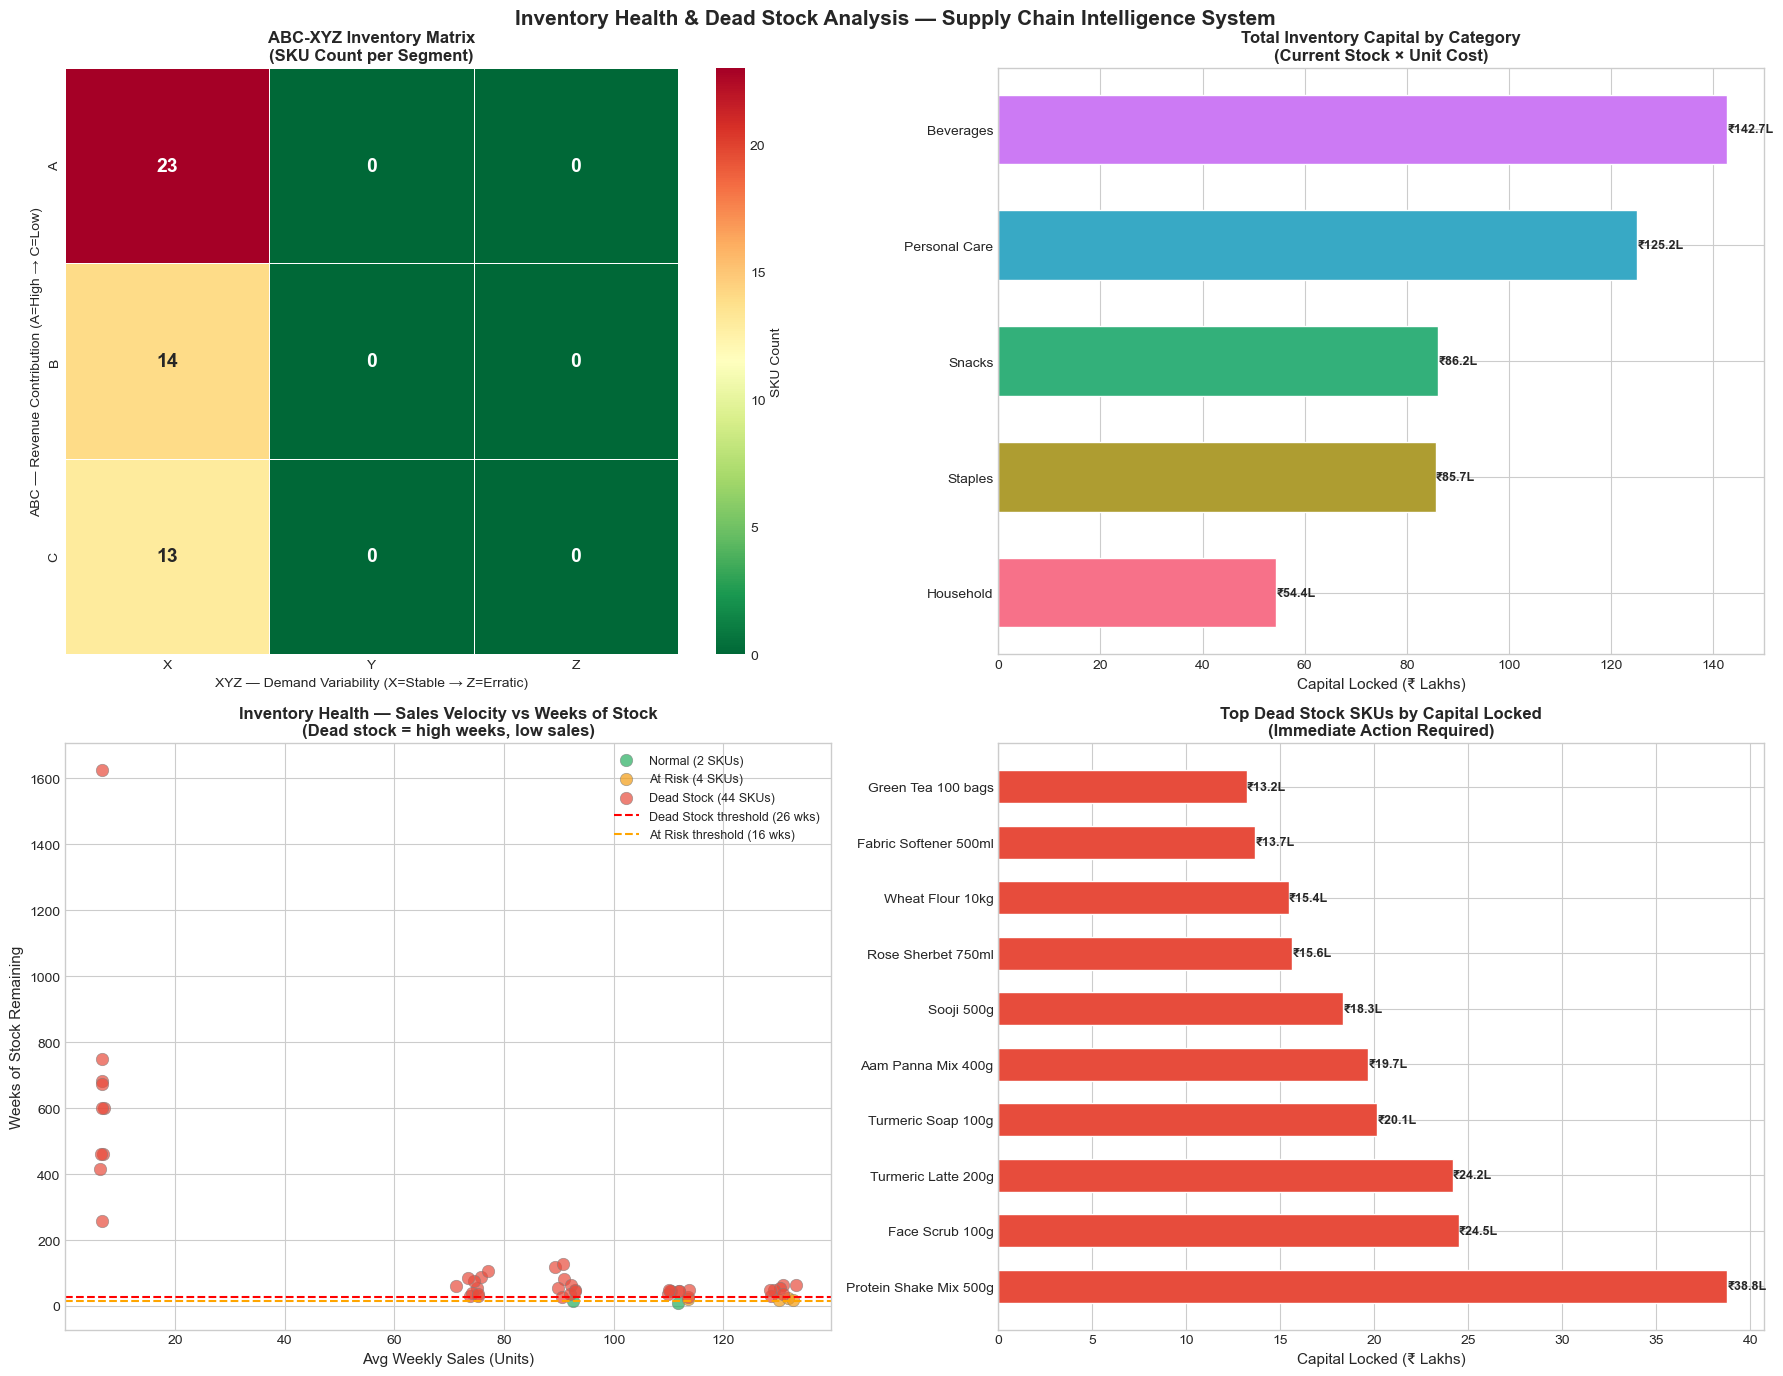

✅ Inventory health charts saved!


In [7]:
# ============================================================
# STEP 5: Inventory Health Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Inventory Health & Dead Stock Analysis — Supply Chain Intelligence System',
             fontsize=15, fontweight='bold')

# ── Chart 1: ABC-XYZ Heatmap ────────────────────────────────
ax1 = axes[0, 0]
matrix_pivot = inventory_matrix.groupby(
    ['abc_category', 'xyz_category']
)['sku_id'].count().unstack(fill_value=0)

# Ensure correct order
matrix_pivot = matrix_pivot.reindex(index=['A','B','C'], columns=['X','Y','Z'], fill_value=0)

sns.heatmap(
    matrix_pivot,
    annot=True, fmt='d', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    ax=ax1, cbar_kws={'label': 'SKU Count'},
    annot_kws={'size': 14, 'weight': 'bold'}
)
ax1.set_title('ABC-XYZ Inventory Matrix\n(SKU Count per Segment)', fontsize=12, fontweight='bold')
ax1.set_xlabel('XYZ — Demand Variability (X=Stable → Z=Erratic)', fontsize=10)
ax1.set_ylabel('ABC — Revenue Contribution (A=High → C=Low)', fontsize=10)

# ── Chart 2: Capital Locked by Category ─────────────────────
ax2 = axes[0, 1]
capital_by_cat = dead_stock_analysis.groupby('category')['capital_locked_inr'].sum().sort_values(ascending=True)
colors_cat = sns.color_palette('husl', len(capital_by_cat))
bars = ax2.barh(capital_by_cat.index, capital_by_cat.values / 1e5,
                color=colors_cat, edgecolor='white', height=0.6)
ax2.set_xlabel('Capital Locked (₹ Lakhs)', fontsize=11)
ax2.set_title('Total Inventory Capital by Category\n(Current Stock × Unit Cost)',
              fontsize=12, fontweight='bold')
for bar, val in zip(bars, capital_by_cat.values):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'₹{val/1e5:.1f}L', va='center', fontsize=9, fontweight='bold')

# ── Chart 3: Dead Stock vs Normal — Weeks of Stock ──────────
ax3 = axes[1, 0]
dead_stock_analysis['stock_status'] = 'Normal'
dead_stock_analysis.loc[dead_stock_analysis['is_at_risk']    == 1, 'stock_status'] = 'At Risk'
dead_stock_analysis.loc[dead_stock_analysis['is_dead_stock'] == 1, 'stock_status'] = 'Dead Stock'

status_colors = {'Normal': '#27ae60', 'At Risk': '#f39c12', 'Dead Stock': '#e74c3c'}
for status, color in status_colors.items():
    subset = dead_stock_analysis[dead_stock_analysis['stock_status'] == status]
    ax3.scatter(subset['avg_weekly_sales'], subset['weeks_of_stock'],
                c=color, label=f'{status} ({len(subset)} SKUs)',
                s=80, alpha=0.7, edgecolors='grey', linewidth=0.5)

ax3.axhline(y=26, color='red',    linestyle='--', linewidth=1.5, label='Dead Stock threshold (26 wks)')
ax3.axhline(y=16, color='orange', linestyle='--', linewidth=1.5, label='At Risk threshold (16 wks)')
ax3.set_xlabel('Avg Weekly Sales (Units)', fontsize=11)
ax3.set_ylabel('Weeks of Stock Remaining',  fontsize=11)
ax3.set_title('Inventory Health — Sales Velocity vs Weeks of Stock\n(Dead stock = high weeks, low sales)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)

# ── Chart 4: Top 10 Dead Stock by Capital Locked ────────────
ax4 = axes[1, 1]
top_dead = dead_stock_skus.sort_values('capital_locked_inr', ascending=False).head(10)
if len(top_dead) > 0:
    colors_dead = ['#e74c3c'] * len(top_dead)
    bars4 = ax4.barh(
        top_dead['product_name'].str[:25],
        top_dead['capital_locked_inr'] / 1e5,
        color=colors_dead, edgecolor='white', height=0.6
    )
    ax4.set_xlabel('Capital Locked (₹ Lakhs)', fontsize=11)
    ax4.set_title('Top Dead Stock SKUs by Capital Locked\n(Immediate Action Required)',
                  fontsize=12, fontweight='bold')
    for bar, val in zip(bars4, top_dead['capital_locked_inr'].values):
        ax4.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'₹{val/1e5:.1f}L', va='center', fontsize=9, fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'No Dead Stock SKUs\nDetected',
             ha='center', va='center', fontsize=14, color='green',
             transform=ax4.transAxes)
    ax4.set_title('Top Dead Stock SKUs', fontsize=12, fontweight='bold')

plt.tight_layout()
chart_path = r'D:\Projects\End-to-end projects\8. Supply Chain Intelligence\Dashboard\Screenshots\inventory_health.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print("✅ Inventory health charts saved!")

In [8]:
# ============================================================
# Save all inventory analysis outputs
# ============================================================

processed_path = r'D:\Projects\End-to-end projects\8. Supply Chain Intelligence\Data\Processed'

# Save ABC-XYZ matrix
inventory_matrix.to_csv(processed_path + r'\inventory_abc_xyz.csv', index=False)

# Save dead stock analysis
dead_stock_analysis.to_csv(processed_path + r'\dead_stock_analysis.csv', index=False)

print("✅ All inventory analysis files saved!")
print(f"\n🎯 INTERVIEW-READY HEADLINE NUMBERS:")
print(f"{'='*55}")
print(f"Total SKUs Analyzed:              {len(dead_stock_analysis)}")
print(f"A-Category SKUs (Top Revenue):    {len(inventory_matrix[inventory_matrix['abc_category']=='A'])}")
print(f"Dead Stock SKUs (>26 weeks):      {len(dead_stock_skus)}")
print(f"At Risk SKUs (16-26 weeks):       {len(at_risk_skus)}")
print(f"Capital in Dead Stock:            ₹{total_dead_value:,.0f}")
print(f"Capital At Risk:                  ₹{total_risk_value:,.0f}")
print(f"Total Capital Exposure:           ₹{(total_dead_value+total_risk_value):,.0f}")
print(f"\nHighest Risk Segment:             CZ (Low value, Erratic demand)")
print(f"Safest Segment:                   AX (High value, Stable demand)")
print(f"\n✅ Files saved:")
print(f"   inventory_abc_xyz.csv")
print(f"   dead_stock_analysis.csv")

✅ All inventory analysis files saved!

🎯 INTERVIEW-READY HEADLINE NUMBERS:
Total SKUs Analyzed:              50
A-Category SKUs (Top Revenue):    23
Dead Stock SKUs (>26 weeks):      44
At Risk SKUs (16-26 weeks):       4
Capital in Dead Stock:            ₹46,681,200
Capital At Risk:                  ₹2,274,519
Total Capital Exposure:           ₹48,955,719

Highest Risk Segment:             CZ (Low value, Erratic demand)
Safest Segment:                   AX (High value, Stable demand)

✅ Files saved:
   inventory_abc_xyz.csv
   dead_stock_analysis.csv
